# Introduction

This analysis's goal is answering the question: When is GeneralGoldenCat's server going to going to pass 1000 users.

First we are going to begin with installing required packages (uncomment and run for all the packages to download, notebook package required first):

In [164]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install matplotlib

And now we can import required libraries:

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Data extraction

As a member of moderation, the author could use advanced discord server tools such as member list, however, they did not provide information about users that left. Discord ToS forbids any form of script-based or bot-based message scrapping, so without day zero implemented bot that scans events, there is no way of automatically extracting historical data without braking existing rules.

All the data that was required for further analysis was gathered manually by the author after reading through all join messages from `#chat-general` (until 20.04.2026) and (from 20.04.2026) from `#welcome_new_members` channel. Those messages included basic discord join event messages, and after configuring the bot on the server, reading through filtered messages of welcome bot `Carl-bot`. The message template from Carl-bot is as follows:

```
Carl bot (%timestamp): Hello, (%username), welcome to GeneralGoldenCat's Server. You are the (%currnumberofuser) st member to join.
```

The only two pieces of information required for analysis are `timestamp` and `currnumberofuser`. `timestamp` will help up with daily analysis, and `currnumberofuser` will help us with calculating members that joined (number rises up), members that left (there is no explicit leave message, but when users leave `currnumberofuser` is either stagnant or higher than before).

All the data was gathered to file user_net_growth.csv. File contains such data as:

- timestamp - Date of data aggregation
- user_gained - Users that joined the server that day
- user_lost - Users that left the server that day
- user_net_growth - Users that server gained that day (user_gained - user_lost)
- total_user - Total amount of user at the end of the day (after last join was concluded)

The data gathered does not perfectly show the user net dynamics, as there were some records missing and there is no clear timestamp for when and which user did leave. The users leaving are deduced based on the total number of users shown in the user joined message and the loss is aggregated to the day the timestamp has shown loss (by showing same total or less than before), so when there were days where no users left, the loss might not have been aggregated properly.

Now we import the data from the csv file:

In [166]:
user_data = pd.read_csv('user_net_growth.csv')  # Load user data from a CSV file

user_data.head()  # Display the first few rows of the dataset

,timestamp,user_gained,user_lost,user_net_growth,total_users
0,08-03-2026,2,0,2,2
1,09-03-2026,1,1,0,2
2,10-03-2026,0,0,0,2
3,11-03-2026,0,0,0,2
4,12-03-2026,0,0,0,2


# 3. Data profiling

In this chapter, the author undertook the process of data profiling, checking data corectness, format and completeness.

Let's start with overall exploration

In [167]:
user_data.info()  # Get information about the dataset, including data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   timestamp        134 non-null    str  
 1   user_gained      134 non-null    int64
 2   user_lost        134 non-null    int64
 3   user_net_growth  134 non-null    int64
 4   total_users      134 non-null    int64
dtypes: int64(4), str(1)
memory usage: 5.4 KB


As we can see, the data above shows that there are four integer columns, which by exploring context seems okay. We can also see one string value - timestamp. That column shall be converted to Date during data cleaning and transformation process. We can also see That there are 133 entries and it seems that we have complete 133 non-null values in each column, which points towards data completness. We will confirm this by summing non-null values:

In [168]:
user_data.isnull().sum()

timestamp          0
user_gained        0
user_lost          0
user_net_growth    0
total_users        0
dtype: int64

As we can see above, data is complete.

Now we will the integer values spread:

In [169]:
user_data.describe()

,user_gained,user_lost,user_net_growth,total_users
count,134.000000,134.000000,134.000000,134.000000
mean,3.194030,0.537313,2.634328,126.626866
std,2.999944,0.772232,2.843119,120.613387
min,0.000000,0.000000,-1.000000,2.000000
25%,1.000000,0.000000,0.000000,11.250000
50%,3.000000,0.000000,2.000000,72.500000
75%,5.000000,1.000000,4.000000,235.250000
max,12.000000,4.000000,11.000000,356.000000


The data (besides total_users, which is a growing value of all users) seems compact. The values are not spread by a lot.

Now let's check data uniqueness:

In [170]:
user_data.nunique()

timestamp          134
user_gained         13
user_lost            5
user_net_growth     12
total_users         93
dtype: int64

In `user_gained`, `user_lost` and `user_net_growth` we can see that there are many recurring values. There are a lot unique values in total_users, which seems correct based on the information that user base is slightly growing. All `timestamp` values being unique show that there are no line duplicates, which mean we can skip line deduplicating process during the data cleaning.

Now let's check if values are properly calculated. The values we need to check are user_net_growth and total_users:

In [171]:
for index in range(len(user_data)):
    if user_data.loc[index, 'user_gained'] - user_data.loc[index, 'user_lost'] != user_data.loc[index, 'user_net_growth']:
        print(user_data.loc[index])
    if index > 0:
        if user_data.loc[index, 'total_users'] != user_data.loc[index - 1, 'total_users'] + user_data.loc[index, 'user_net_growth']:
            print(user_data.loc[index])

timestamp          18-07-2026
user_gained                 5
user_lost                   1
user_net_growth             1
total_users               354
Name: 132, dtype: object
timestamp          18-07-2026
user_gained                 5
user_lost                   1
user_net_growth             1
total_users               354
Name: 132, dtype: object


As there is no output, it seems that all the values are calculated properly.

Now that we did complete data profiling, we can go over to data cleaning

# 4. Data transformation and cleaning

We do not really need to do a lot with the data. It seems that data is pretty much complete and clean as it is. All we need to do, before data exploration, is transform string date into date:

In [172]:
user_data['timestamp'] = pd.to_datetime(user_data['timestamp'], format='%d-%m-%Y')  # Convert timestamp to datetime format

Now we check:

In [173]:
user_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        134 non-null    datetime64[us]
 1   user_gained      134 non-null    int64         
 2   user_lost        134 non-null    int64         
 3   user_net_growth  134 non-null    int64         
 4   total_users      134 non-null    int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 5.4 KB


And let's see values in the table:

In [174]:
user_data.head()

,timestamp,user_gained,user_lost,user_net_growth,total_users
0,2026-03-08,2,0,2,2
1,2026-03-09,1,1,0,2
2,2026-03-10,0,0,0,2
3,2026-03-11,0,0,0,2
4,2026-03-12,0,0,0,2


Seems everything is in order, now we can go over to the data exploration process

# 5. Data exploration

We will start with exploring what kind of trends can we find in the given data. All the data will be aggregated by the date.

Let's start with daily, weekly and monthly aggregation!

In [175]:
# Aggregations
daily_sum_aggregate = user_data
weekly_sum_aggregate = user_data.resample('W', on='timestamp').sum().reset_index()
monthly_sum_aggregate = user_data.resample('MS', on='timestamp').sum().reset_index()
weekly_avg_aggregate = user_data.resample('W', on='timestamp').mean().reset_index()
monthly_avg_aggregate = user_data.resample('MS', on='timestamp').mean().reset_index()

titles_list = ['Daily', 'Weekly', 'Monthly'] # Titles for the plots
list_of_aggregates = [daily_sum_aggregate, weekly_sum_aggregate, monthly_sum_aggregate] # List of aggregated dataframes

monthly_sum_aggregate.head()

,timestamp,user_gained,user_lost,user_net_growth,total_users
0,2026-03-01,11,2,9,82
1,2026-04-01,37,4,33,652
2,2026-05-01,143,24,119,2995
3,2026-06-01,158,25,133,7003
4,2026-07-01,79,17,59,6236


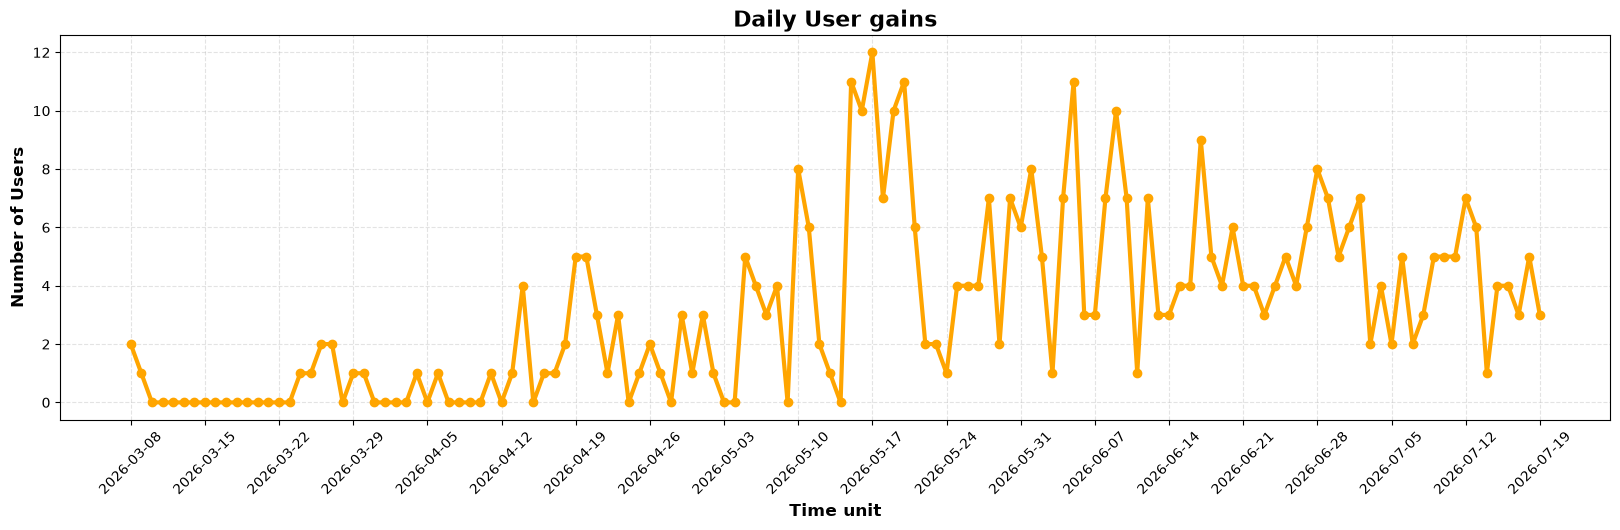

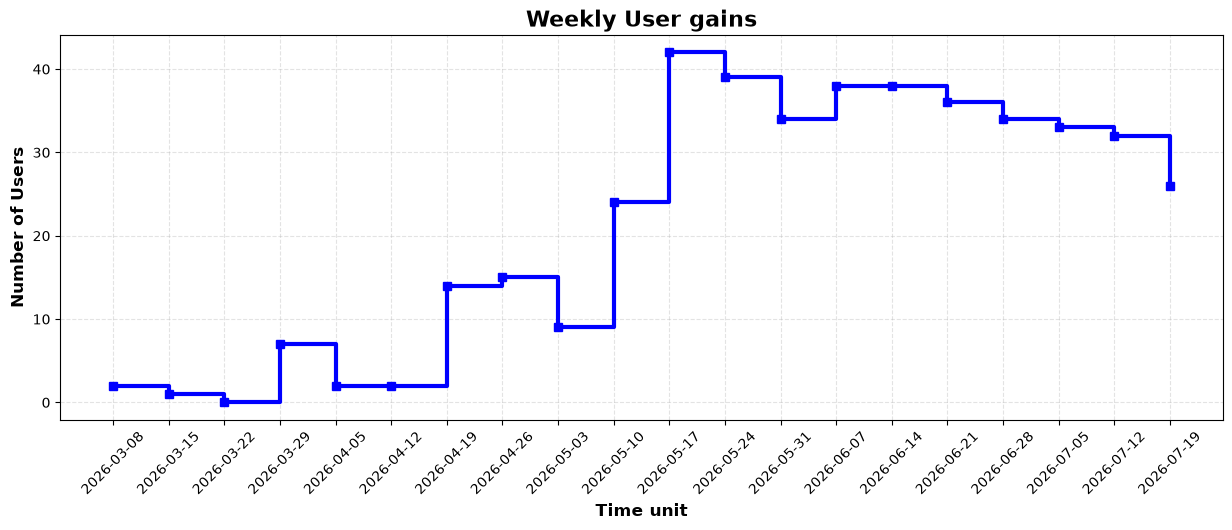

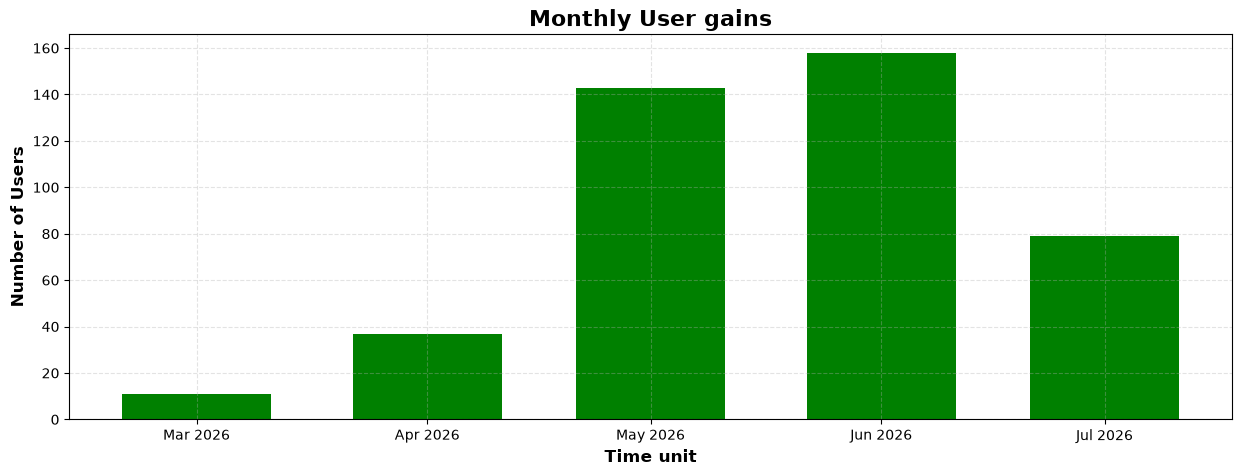

In [176]:
def plot_user_gained(user_gained_list, titles_list):
    for data_title_pair in zip(user_gained_list, titles_list):
        
        if data_title_pair[1] == 'Daily':
            fig, ax = plt.subplots(figsize=(20, 5))  # Create a figure and axis for the 
            ax.plot( # Create a line plot for user gains over time
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_gained'],
                color='orange',
                linewidth=3,
                marker='o'
                )
        elif data_title_pair[1] == 'Weekly':
            fig, ax = plt.subplots(figsize=(15, 5))  # Create a figure and axis for the 
            ax.step(
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_gained'],
                where='post',
                color='blue',
                linewidth=3,
                marker='s'
            )
        else:  # Monthly
            fig, ax = plt.subplots(figsize=(15, 5))  # Create a figure and axis for the 
            ax.bar(
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_gained'],
                color='green',
                width=20,
            )

        ax.set_title( # Plot title with custom font properties
            label= data_title_pair[1] + ' User gains', # plot title
            fontsize=16,
            fontweight='bold'
            ) 

        ax.set_xlabel( # Label the x-axis
            xlabel='Time unit',
            fontsize=12,
            fontweight='bold'
            )  

        ax.set_ylabel( # Label the y-axis
            ylabel='Number of Users gained',
            fontsize=12,
            fontweight='bold'
            )  

        ax.grid(
            which='major',
            linestyle='--',
            alpha=0.35,
        )
        if data_title_pair[1] == 'Daily' or data_title_pair[1] == 'Weekly':
            ax.set_xticks(user_data['timestamp'][::7]) # set x-ticks to every 7th date for better readability
            ax.tick_params(axis='x', rotation=45) # Rotate x-tick labels for better readability
        elif data_title_pair[1] == 'Monthly':
            ax.set_xticks(monthly_sum_aggregate['timestamp'])
            ax.tick_params(axis='x', rotation=0) # Rotate x-tick labels for better readability
            ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))  # Format x-axis labels to show month and year
        
        ax.set_ylabel('Number of Users')  # Label the y-axis
            
        plt.show()  # Show the plot of user growth over time

plot_user_gained(list_of_aggregates, titles_list)  # Call the function to plot user growth

To fill out

Now let's see user losses:

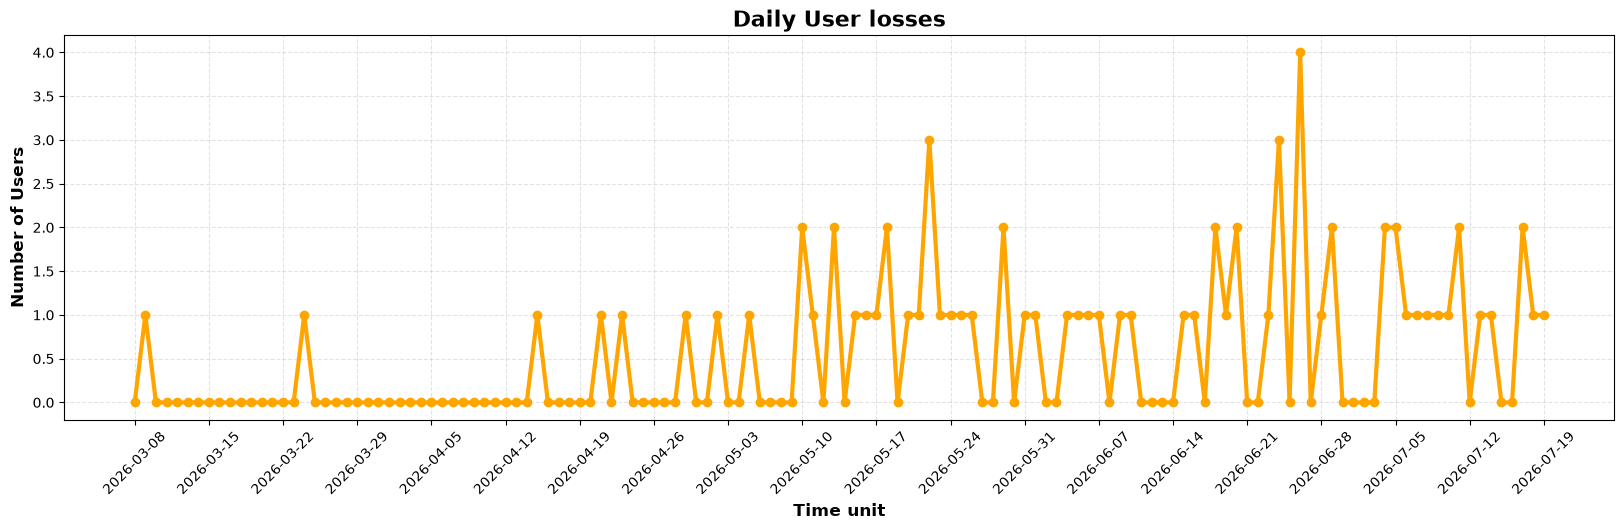

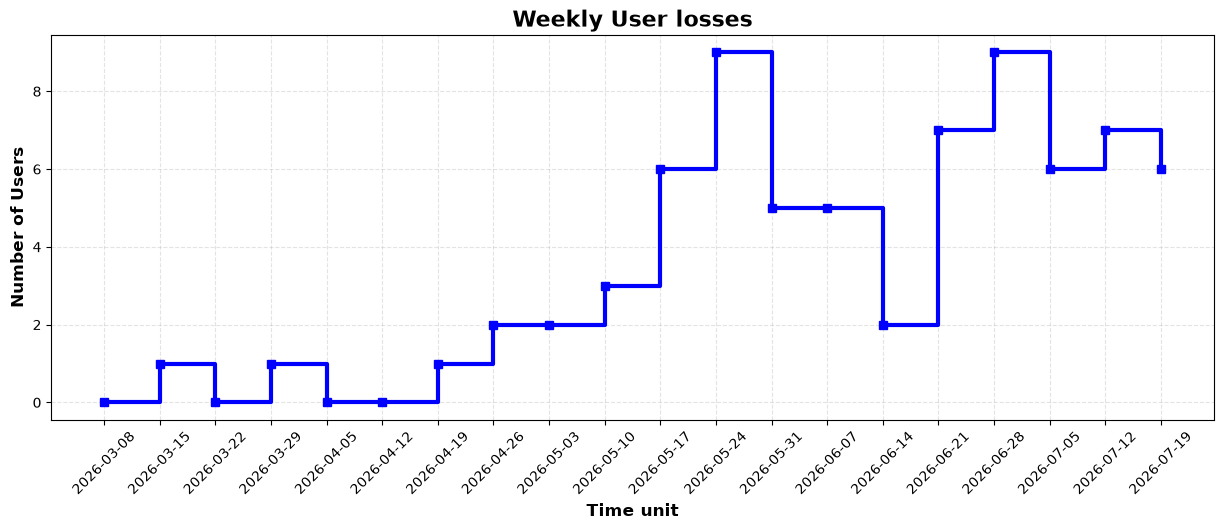

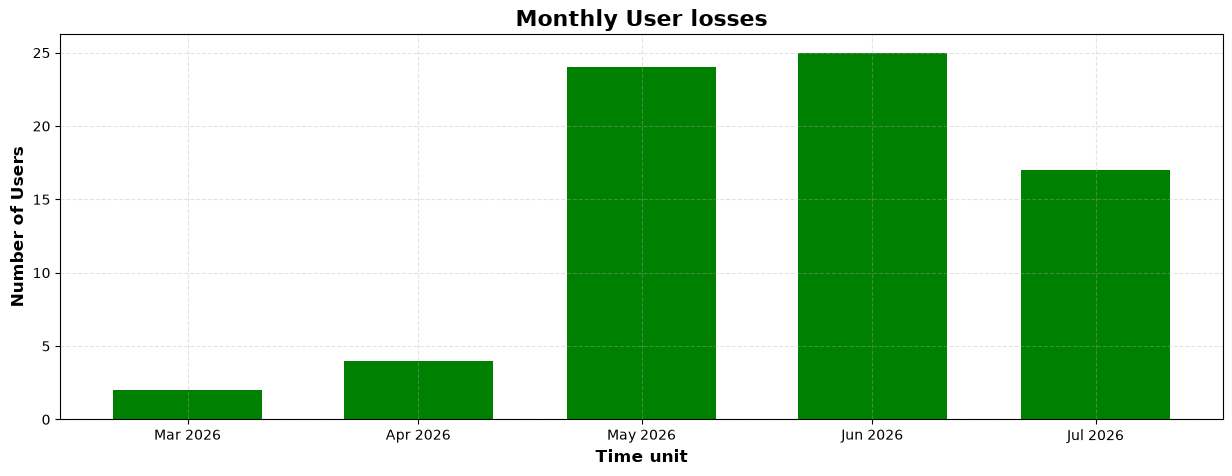

In [178]:
def plot_user_lost(user_lost_list, titles_list):
    for data_title_pair in zip(user_lost_list, titles_list):
        
        if data_title_pair[1] == 'Daily':
            fig, ax = plt.subplots(figsize=(20, 5))  # Create a figure and axis for the 
            ax.plot( # Create a line plot for user gains over time
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_lost'],
                color='orange',
                linewidth=3,
                marker='o'
                )
        elif data_title_pair[1] == 'Weekly':
            fig, ax = plt.subplots(figsize=(15, 5))  # Create a figure and axis for the 
            ax.step(
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_lost'],
                where='post',
                color='blue',
                linewidth=3,
                marker='s'
            )
        else:  # Monthly
            fig, ax = plt.subplots(figsize=(15, 5))  # Create a figure and axis for the 
            ax.bar(
                data_title_pair[0]['timestamp'],
                data_title_pair[0]['user_lost'],
                color='green',
                width=20,
            )

        ax.set_title( # Plot title with custom font properties
            label= data_title_pair[1] + ' User losses', # plot title
            fontsize=16,
            fontweight='bold'
            ) 

        ax.set_xlabel( # Label the x-axis
            xlabel='Time unit',
            fontsize=12,
            fontweight='bold'
            )  

        ax.set_ylabel( # Label the y-axis
            ylabel='Number of Users lost',
            fontsize=12,
            fontweight='bold'
            )  

        ax.grid(
            which='major',
            linestyle='--',
            alpha=0.35,
        )
        if data_title_pair[1] == 'Daily' or data_title_pair[1] == 'Weekly':
            ax.set_xticks(user_data['timestamp'][::7]) # set x-ticks to every 7th date for better readability
            ax.tick_params(axis='x', rotation=45) # Rotate x-tick labels for better readability
        elif data_title_pair[1] == 'Monthly':
            ax.set_xticks(monthly_sum_aggregate['timestamp'])
            ax.tick_params(axis='x', rotation=0) # Rotate x-tick labels for better readability
            ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))  # Format x-axis labels to show month and year
        
        ax.set_ylabel('Number of Users')  # Label the y-axis
            
        plt.show()  # Show the plot of user growth over time

plot_user_lost(list_of_aggregates, titles_list)  # Call the function to plot user growth

Now let's calculate the net worth!


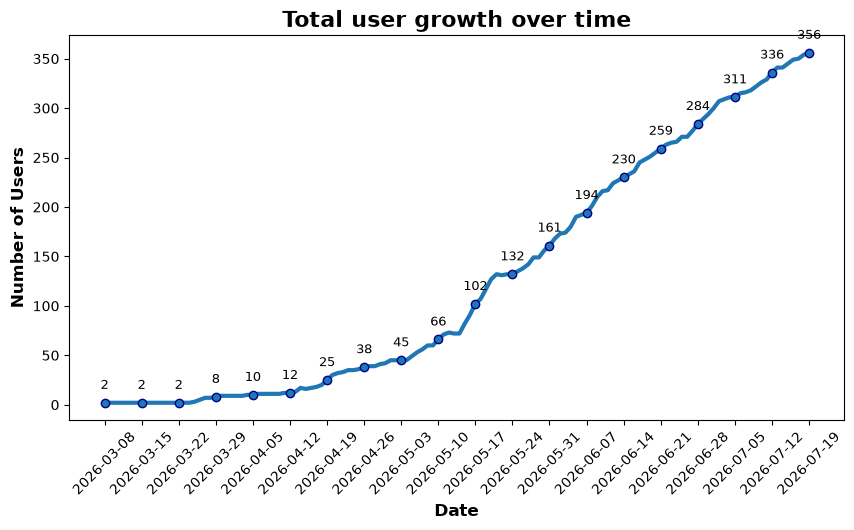

In [177]:
fig, ax = plt.subplots(figsize=(10, 5))  # Create a figure and axis for the plot

ax.plot( # Plot total users over time
    user_data['timestamp'],
    user_data['total_users'],
    linewidth=3,
    marker='o',
    markersize=6, 
    markevery=7,
    markeredgecolor='darkblue',
        )  

ax.set_title( # Plot title with custom font properties
    label='Total user growth over time', # plot title
    fontsize=16,
    fontweight='bold'
    ) 

ax.set_xlabel( # Label the x-axis
    xlabel='Date',
    fontsize=12,
    fontweight='bold'
    )  

ax.set_ylabel( # Label the y-axis
    ylabel='Number of Users',
    fontsize=12,
    fontweight='bold'
    )  

# Add value labels every 7 points
for i in range(0, len(user_data), 7):
    ax.annotate(
        f"{user_data['total_users'].iloc[i]:,}",
        (
            user_data['timestamp'].iloc[i],
            user_data['total_users'].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )



ax.set_xticks(user_data['timestamp'][::7]) # set x-ticks to every 7th date for better readability
ax.tick_params(axis='x', rotation=45) # Rotate x-tick labels for better readability

ax.set_ylabel('Number of Users')  # Label the y-axis

plt.show()  # Show the plot of user growth over time